# Pancreas ROI Size Analysis

Before choosing a fixed crop size, we analyze the pancreas bounding-box dimensions
across the entire PANORAMA dataset after resampling to isotropic voxel spacing.

This allows the crop size to be selected based on the dataset rather than
an arbitrary value.

In [1]:
# ============================================================
# Project Setup
# ============================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from importlib import reload

In [2]:
import pandas as pd
import numpy as np

from src.io import (
    list_ct_cases,
    load_case,
)

from src.preprocessing import (
    resample_case,
    get_structure_bbox,
    bbox_size,
    analyze_roi_sizes
    
)

In [3]:
roi_df = analyze_roi_sizes()

roi_df.head()

25/557
50/557
75/557
100/557
125/557
150/557
175/557
200/557
225/557
250/557
275/557
300/557
325/557
350/557
375/557
400/557
425/557
450/557
475/557
500/557
525/557
550/557
557/557


,study_id,depth,height,width,volume
0,100000_00001,92,57,134,702696
1,100001_00001,96,56,114,612864
2,100002_00001,99,103,104,1060488
3,100003_00001,82,78,106,677976
4,100004_00001,69,67,137,633351


In [4]:
roi_df.describe()

,depth,height,width,volume
count,557.000000,557.000000,557.000000,5.570000e+02
mean,83.901257,74.746858,125.763016,8.140789e+05
std,14.425545,15.720885,23.033941,3.203328e+05
min,15.000000,16.000000,16.000000,3.840000e+03
25%,76.000000,64.000000,111.000000,5.916680e+05
50%,84.000000,75.000000,126.000000,7.800000e+05
75%,92.000000,85.000000,141.000000,1.007916e+06
max,135.000000,119.000000,196.000000,2.345880e+06


In [5]:
roi_df.sort_values(
    "volume",
    ascending=False,
).head(20)

,study_id,depth,height,width,volume
231,100227_00001,120,113,173,2345880
51,100047_00005,83,117,196,1903356
48,100047_00002,84,119,188,1879248
437,100429_00001,99,113,166,1857042
393,100387_00001,113,107,143,1729013
295,100289_00001,87,104,189,1710072
327,100321_00001,117,102,140,1670760
49,100047_00003,84,108,181,1642032
436,100428_00001,120,95,144,1641600
279,100273_00001,99,114,143,1613898


In [8]:
roi_df[["depth", "height", "width"]].quantile(
    [
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,depth,height,width
0.50,84.0,75.0,126.00
0.75,92.0,85.0,141.00
0.90,101.0,94.0,154.00
0.95,105.2,100.2,163.00
0.99,120.0,113.0,179.32


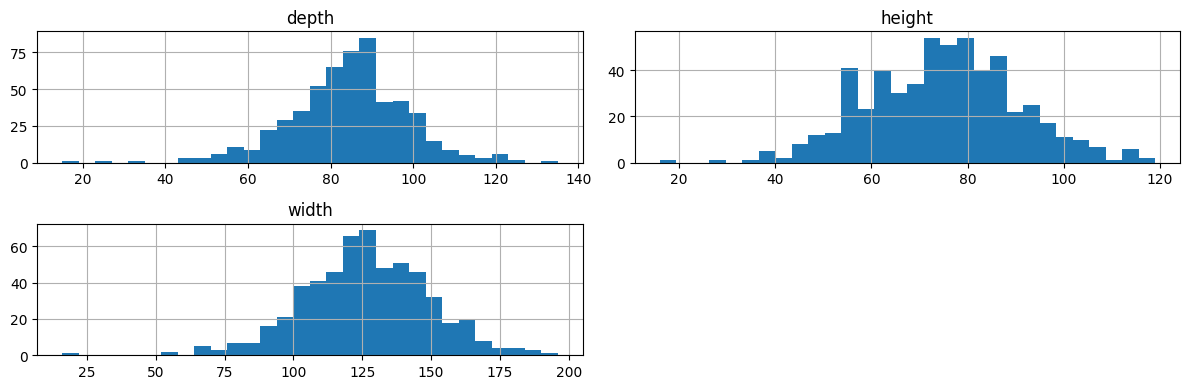

In [9]:
import matplotlib.pyplot as plt

roi_df[["depth", "height", "width"]].hist(
    figsize=(12, 4),
    bins=30,
)

plt.tight_layout()
plt.show()